In [1]:
import torch
import torch.nn as nn
import torch.linalg as la
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import requests
import tarfile
from PIL import Image
import sys
import hydra
from omegaconf import OmegaConf

# Add the project source directory to the Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.data.dataset import load_mnist
from src.utils.losses import compute_logits
from src.train import get_target_distributions
from src.utils.evaluation import (
    get_all_predictions,
    get_classification_report_and_cm,
    calculate_ece_and_reliability_diagram,
    calculate_nll_and_brier_score,
    get_ood_confidences_and_plot,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/home/e1444/repos/dnf/ENV/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/e1444/repos/dnf/ENV/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated

Using device: cuda


In [70]:
# ----------------------------
# Configuration
# ----------------------------
# Define the configuration structure and load the files in a Hydra-like way
conf_path = os.path.join(project_root, 'conf')

# Start with the base config, which may contain defaults or other top-level settings
cfg = OmegaConf.load(os.path.join(conf_path, 'config.yaml'))

# Define which specific configs to load for this run
# This makes it easy to switch models or datasets later
model_config_name = "dglow_resnet.yaml" 
data_config_name = "mnist.yaml"
training_config_name = "default.yaml"

# Create a structured config by merging the components
cfg = OmegaConf.merge(
    cfg,
    {
        "model": OmegaConf.load(os.path.join(conf_path, 'model', model_config_name)),
        "data": OmegaConf.load(os.path.join(conf_path, 'data', data_config_name)),
        "training": OmegaConf.load(os.path.join(conf_path, 'training', training_config_name)),
    }
)

In [3]:
# ----------------------------
# Data Loading
# ----------------------------
# The load_mnist function from the project returns DataLoaders.
# We need the underlying dataset for some evaluation metrics.
cfg.data.dataset.path = os.path.join(project_root, cfg.data.dataset.path)
_, test_loader = load_mnist(cfg.data)
test_dataset = test_loader.dataset

print(f"Loaded MNIST test dataset with {len(test_dataset)} samples.")

Loaded MNIST test dataset with 10000 samples.


/home/e1444/repos/dnf/ENV/lib/python3.11/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [91]:
# --- 1. Instantiate a new model ---
model = hydra.utils.instantiate(cfg.model, _convert_="partial").to(device)

# --- 2. Load the checkpoint file ---
CHECKPOINT_PATH = "/home/e1444/scratch/dnf/logs/2025-11-17/11-58-32/checkpoint_epoch_20.pth" # Specify
if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(f"Checkpoint file not found at '{CHECKPOINT_PATH}'. Please update the path.")

print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

# --- 3. Load the states into the new instances ---
model.load_state_dict(checkpoint['model_state_dict'])

# Load the trained means and variances for correct evaluation
trainable_means = checkpoint['trainable_means'].to(device)
trainable_v = checkpoint['trainable_v'].to(device)

# --- 4. Set the model to evaluation mode ---
model.eval()

print("Model loaded successfully and set to evaluation mode.")

Loading checkpoint from /home/e1444/scratch/dnf/logs/2025-11-17/11-58-32/checkpoint_epoch_15.pth...
Model loaded successfully and set to evaluation mode.


In [92]:
vars = torch.log(1 + torch.exp(trainable_v)) + 1e-3
print(vars.max(dim=1))
print(vars.min(dim=1))
print(vars.mean(dim=1))

torch.return_types.max(
values=tensor([0.8452, 0.1147, 0.6742, 0.0489, 0.5304, 0.1228, 0.6745, 0.0888, 0.7257,
        0.1484], device='cuda:0'),
indices=tensor([  0, 500,   2, 144,   4, 105,   6, 156,   8, 278], device='cuda:0'))
torch.return_types.min(
values=tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010,
        0.0010], device='cuda:0'),
indices=tensor([754, 406, 188,  60,  77,  37, 636, 630, 116, 627], device='cuda:0'))
tensor([0.0040, 0.0019, 0.0037, 0.0025, 0.0032, 0.0036, 0.0036, 0.0029, 0.0039,
        0.0033], device='cuda:0')


In [93]:
trainable_means

tensor([[ 0.9381, -0.1055,  0.0296,  ...,  0.0211, -0.0118,  0.0634],
        [ 0.0961,  0.8419,  0.2193,  ..., -0.0204,  0.0895, -0.1988],
        [-0.1540,  0.0309,  0.9326,  ...,  0.1285,  0.0804, -0.0664],
        ...,
        [-0.1324,  0.0120, -0.0349,  ...,  0.0294,  0.1871, -0.0282],
        [-0.1384, -0.0313,  0.1256,  ..., -0.0812, -0.1331,  0.1187],
        [-0.0492, -0.0938, -0.0427,  ..., -0.1228,  0.0472, -0.0075]],
       device='cuda:0')

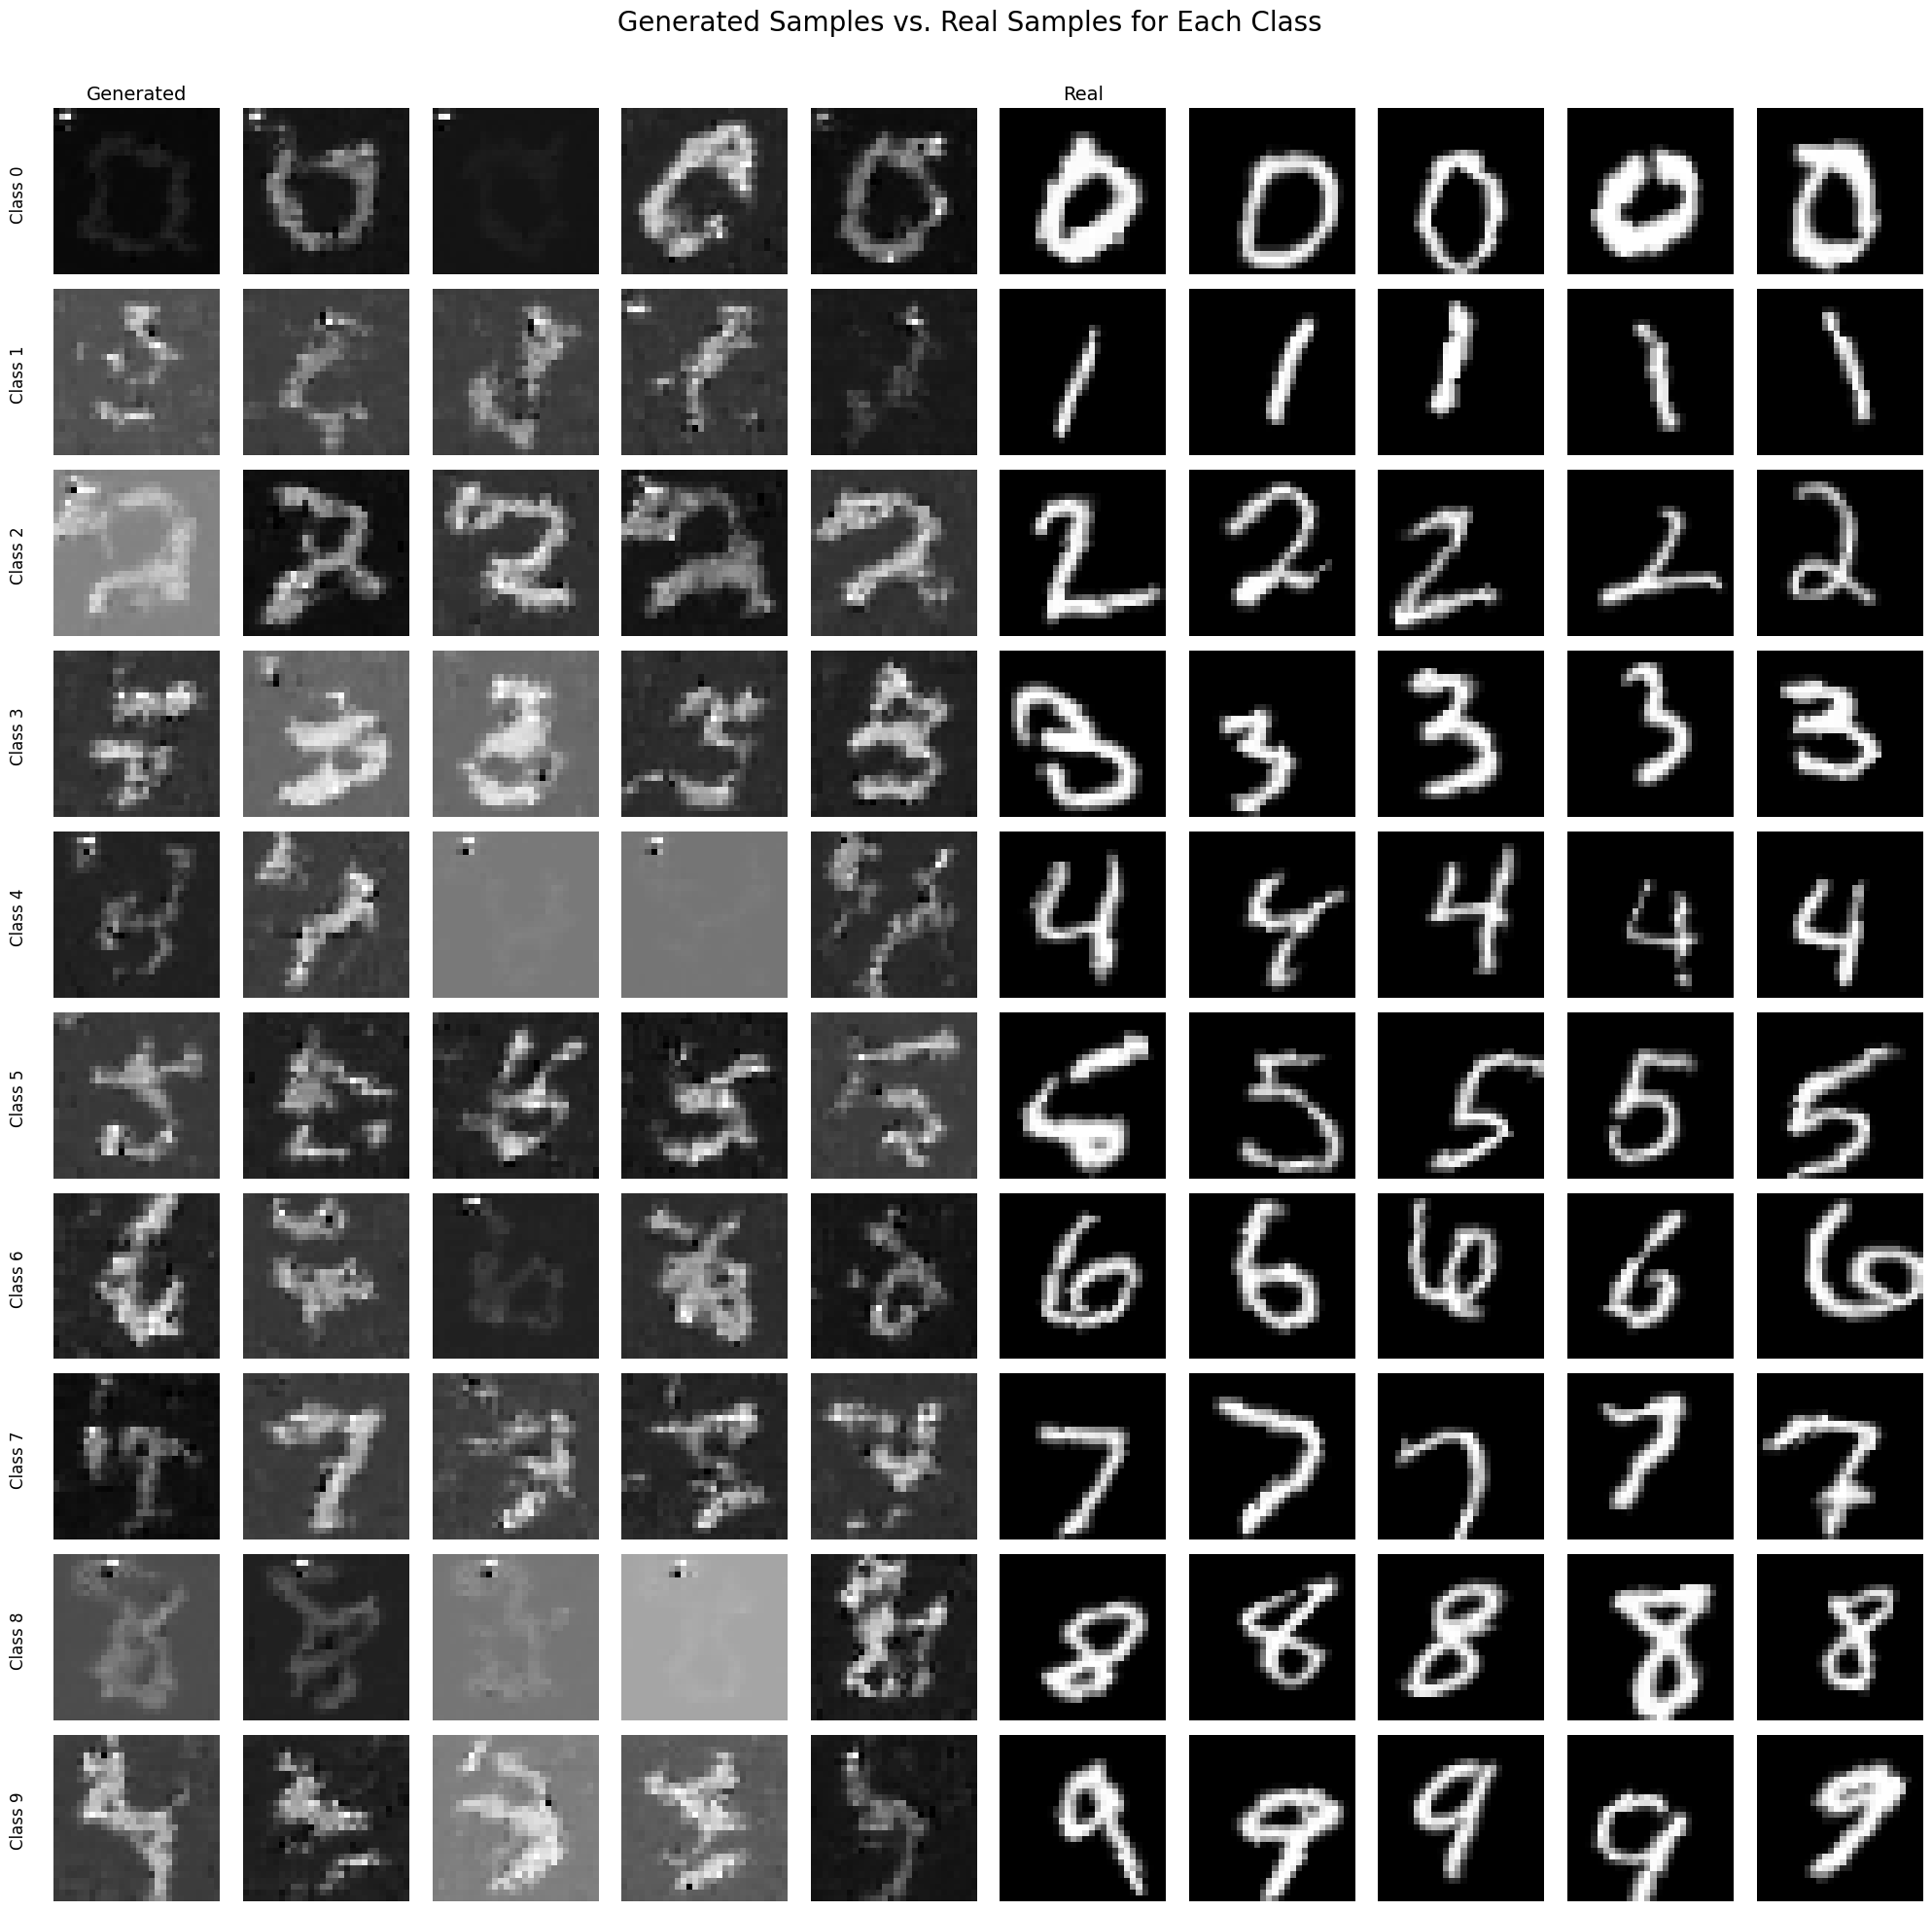

In [94]:
# --- 5. Generate and Visualize Class-wise Samples vs. Real Samples ---
# Define grid size
n_rows = 10  # One row for each class (0-9)
n_cols = 5   # Number of samples to generate/show per class

# Prepare real images by grouping them by class
real_images_by_class = {i: [] for i in range(n_rows)}
for img, label in test_dataset:
    if len(real_images_by_class[label]) < n_cols:
        real_images_by_class[label].append(img)

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(n_cols * 4, n_rows * 2))
fig.suptitle('Generated Samples vs. Real Samples for Each Class', fontsize=20)

with torch.no_grad():
    for class_idx in range(n_rows):
        # --- Generate and plot new images ---
        for sample_idx in range(n_cols):
            # Create the new, tighter target distributions
            modified_target_dists = get_target_distributions(
                trainable_means, trainable_v, cfg.training.num_classes
            )
            
            # Sample from the tighter distribution of the predicted class
            z_sample = modified_target_dists[class_idx].sample()
            z_sample = z_sample.view(1, 1, 28, 28)
            
            generated_image, _ = model.inverse(z_sample)
            
            # Plot
            ax = axes[class_idx, sample_idx]
            ax.imshow(generated_image.squeeze().cpu().numpy(), cmap='gray')
            ax.axis('off')
            if sample_idx == 0 and class_idx == 0:
                ax.set_title("Generated", fontsize=14)

        # --- Plot real images ---
        for sample_idx in range(n_cols):
            # Get a real image for the current class
            real_image = real_images_by_class[class_idx][sample_idx]
            
            # Plot
            ax = axes[class_idx, n_cols + sample_idx]
            ax.imshow(real_image.squeeze().numpy(), cmap='gray')
            ax.axis('off')
            if sample_idx == 0 and class_idx == 0:
                ax.set_title("Real", fontsize=14)

        # Add a label for the class on the far left of each row
        axes[class_idx, 0].text(-5, 14, f"Class {class_idx}", verticalalignment='center', horizontalalignment='right', fontsize=12, rotation=90)


plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()